<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Denoising Autoencoder in PyTorch</b>
</h1>
<div style="font-family:'Times New Roman';">
Same autoencoder but now with torch, and with a twist. Instead of feeding the clean image and asking for the clean image back, noise is added to the input and the target stays clean. So the network is forced to learn the digit shape and not just copy pixels.
</div>

## why denoising

a plain autoencoder can cheat if the code is big enough, it just passes the pixels through. if the input is damaged then copying is useless, the only way to get a low loss is to actually understand what a digit looks like.

so : `input = image + noise` and `target = clean image`.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

digits = load_digits()
X = digits.data / 16.0
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
print(X_train.shape, X_test.shape)

torch.Size([1437, 64]) torch.Size([360, 64])


## adding the noise
gaussian noise on top of the pixels, then clipped back into 0 to 1 so it still looks like an image.

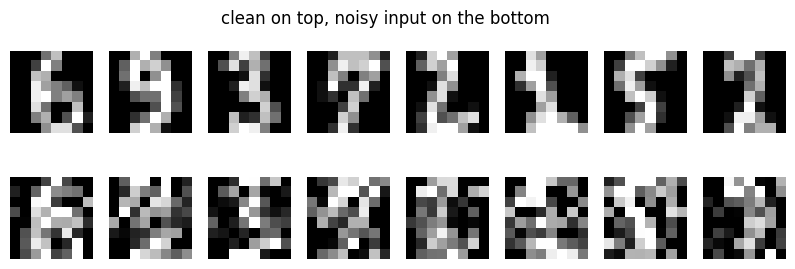

In [14]:
def add_noise(t, level=0.4):
    noisy = t + level * torch.randn_like(t)
    return torch.clamp(noisy, 0.0, 1.0)

noisy_test = add_noise(X_test)

fig, ax = plt.subplots(2, 8, figsize=(10,3))
for i in range(8):
    ax[0,i].imshow(X_test[i].reshape(8,8), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(noisy_test[i].reshape(8,8), cmap='gray'); ax[1,i].axis('off')
plt.suptitle('clean on top, noisy input on the bottom')
plt.show()

## the model
using `nn.Sequential` so the encoder and decoder stay as two seperate blocks and i can still call them one by one.

In [3]:
encoder = nn.Sequential(
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU()
)

decoder = nn.Sequential(
    nn.Linear(16, 32), nn.ReLU(),
    nn.Linear(32, 64), nn.Sigmoid()
)

model = nn.Sequential(encoder, decoder)
print(model)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (1): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Sigmoid()
  )
)


In [4]:
print("total parameters :", sum(p.numel() for p in model.parameters()))

total parameters : 5264


## training
loss compares the output with the **clean** image even though the input was noisy. new noise is generated every epoch so it never sees the same corrupted image twice.

In [5]:
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.002)

train_hist, test_hist = [], []

for epoch in range(1500):
    model.train()
    noisy = add_noise(X_train)          # fresh noise each epoch
    out = model(noisy)
    loss = loss_fn(out, X_train)        # target is the clean one

    opt.zero_grad()
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        t_loss = loss_fn(model(add_noise(X_test)), X_test)

    train_hist.append(loss.item())
    test_hist.append(t_loss.item())

    if epoch % 250 == 0:
        print("epoch", str(epoch).rjust(3), " train", round(loss.item(), 4), " test", round(t_loss.item(), 4))

epoch   0  train 0.1796  test 0.1775


epoch 250  train 0.0499  test 0.0495


epoch 500  train 0.0361  test 0.0365


epoch 750  train 0.0334  test 0.0335


epoch 1000  train 0.0315  test 0.0316


epoch 1250  train 0.0303  test 0.0309


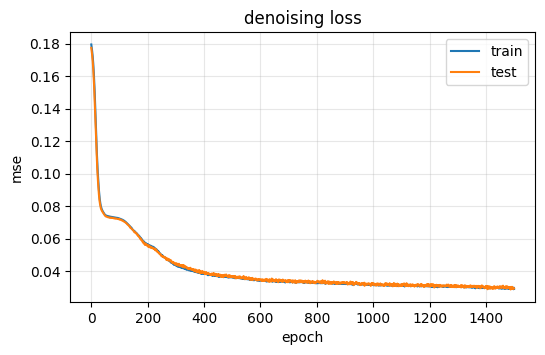

In [6]:
plt.figure(figsize=(6,3.5))
plt.plot(train_hist, label='train')
plt.plot(test_hist, label='test')
plt.xlabel('epoch'); plt.ylabel('mse'); plt.legend(); plt.grid(alpha=.3)
plt.title('denoising loss')
plt.show()

## does it actually clean the image

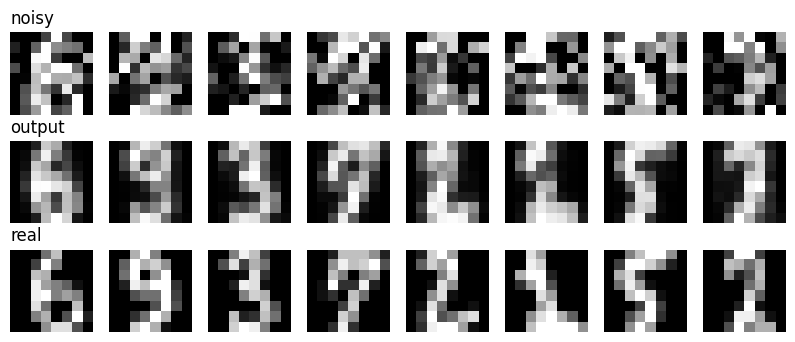

In [7]:
model.eval()
with torch.no_grad():
    cleaned = model(noisy_test)

fig, ax = plt.subplots(3, 8, figsize=(10,4))
for i in range(8):
    ax[0,i].imshow(noisy_test[i].reshape(8,8), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(cleaned[i].reshape(8,8),   cmap='gray'); ax[1,i].axis('off')
    ax[2,i].imshow(X_test[i].reshape(8,8),    cmap='gray'); ax[2,i].axis('off')
ax[0,0].set_title('noisy', loc='left'); ax[1,0].set_title('output', loc='left'); ax[2,0].set_title('real', loc='left')
plt.show()

In [9]:
with torch.no_grad():
    err_noisy = ((noisy_test - X_test) ** 2).mean().item()
    err_clean = ((cleaned - X_test) ** 2).mean().item()

print("error of the noisy input vs clean :", round(err_noisy, 4))
print("error of the model output vs clean:", round(err_clean, 4))

error of the noisy input vs clean : 0.084
error of the model output vs clean: 0.0297


## how much noise can it take

noise 0.0  output error 0.0188
noise 0.2  output error 0.0209
noise 0.4  output error 0.0298
noise 0.6  output error 0.0412
noise 0.8  output error 0.0537
noise 1.0  output error 0.0641


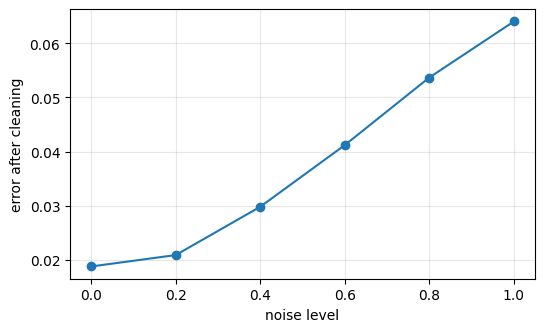

In [10]:
levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
errs = []

with torch.no_grad():
    for lv in levels:
        n = add_noise(X_test, lv)
        e = ((model(n) - X_test) ** 2).mean().item()
        errs.append(e)
        print("noise", lv, " output error", round(e, 4))

plt.figure(figsize=(6,3.5))
plt.plot(levels, errs, 'o-')
plt.xlabel('noise level'); plt.ylabel('error after cleaning')
plt.grid(alpha=.3)
plt.show()

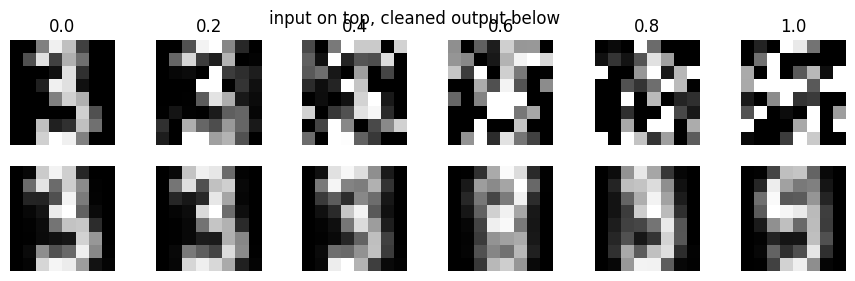

In [11]:
fig, ax = plt.subplots(2, len(levels), figsize=(11,3))
with torch.no_grad():
    for j, lv in enumerate(levels):
        n = add_noise(X_test, lv)
        o = model(n)
        ax[0,j].imshow(n[2].reshape(8,8), cmap='gray'); ax[0,j].set_title(lv); ax[0,j].axis('off')
        ax[1,j].imshow(o[2].reshape(8,8), cmap='gray'); ax[1,j].axis('off')
plt.suptitle('input on top, cleaned output below')
plt.show()

## the 16 number code, coloured by digit

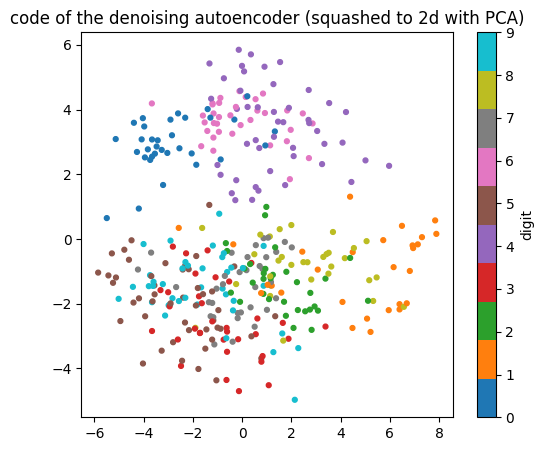

In [12]:
from sklearn.decomposition import PCA

with torch.no_grad():
    codes = encoder(X_test).numpy()

flat = PCA(n_components=2).fit_transform(codes)
plt.figure(figsize=(6,5))
sc = plt.scatter(flat[:,0], flat[:,1], c=y_test, cmap='tab10', s=12)
plt.colorbar(sc, label='digit')
plt.title('code of the denoising autoencoder (squashed to 2d with PCA)')
plt.show()

### quick recap

- trained on noisy input with the clean image as target, so it has to learn the digit shape instead of copying pixels
- at 0.4 noise the noisy image itself is 0.084 away from the clean one, after cleaning its 0.0297, so almost 3 times better
- error grows smoothly with noise, 0.019 with no noise going upto 0.064 at noise 1.0. it never falls off a cliff, the output just keeps getting blurrier and starts looking like an average digit
- torch version is around 10 lines against the full numpy one in notebook 02, but writing the numpy one first is the reason i know whats happening inside `loss.backward()`